## **Human Activity Recognition Using Hidden Markov Models**

This notebook implements a full pipeline for recognising human physical activities from smartphone sensor data using Hidden Markov Models (HMMs). The system processes raw accelerometer and gyroscope signals recorded using the Sensor Logger app, extracts meaningful time-domain and frequency-domain features, and trains a separate Gaussian HMM for each activity. Classification is performed using the Viterbi algorithm, and the model is evaluated on completely unseen recordings.


**Student:** Emmanuella Briggs  
**Device:** Samsung SM-S901U (Android)  
**App:** Sensor Logger v1.60.2  
**Sampling Rate:** 100 Hz (one reading every 10ms)  
**Activities Recorded:** Still, Standing, Walking, Jumping  
**Date:** July 2026

In [11]:
!pip install hmmlearn

## 1. Imports & Configuration

We begin by importing all necessary Python libraries:
- `numpy` and `pandas` for numerical computation and data handling
- `matplotlib` and `seaborn` for all visualisations
- `scipy.fft` for computing Fast Fourier Transforms during feature extraction
- `sklearn.preprocessing.StandardScaler` for Z-score normalisation
- `sklearn.metrics.confusion_matrix` for evaluation
- `hmmlearn.hmm` for building and training Gaussian Hidden Markov Models

We also define all global configuration parameters in one place so they are easy to adjust:
- **SAMPLING_RATE = 100 Hz** : this is the rate at which Sensor Logger recorded data (one sample every 10ms)
- **WINDOW_SIZE = 100 samples** : at 100 Hz, this equals exactly 1 second per window, which is long enough to capture one full walking gait cycle
- **STEP_SIZE = 50 samples** : a 50% overlap between consecutive windows, which doubles the number of training samples without introducing excessive redundancy
- **N_STATES = 4** : the number of internal hidden states per HMM, chosen to match the 4 activities
- **ACTIVITIES** : the four physical activities we aim to classify: still, standing, walking, jumping

In [12]:
import os, glob, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')

SAMPLING_RATE   = 100
WINDOW_SIZE     = 100
STEP_SIZE       = 50
N_STATES        = 4
ACTIVITIES      = ['still', 'standing', 'walking', 'jumping']
ACTIVITY_COLORS = {'still':'#4C72B0', 'standing':'#55A868','walking':'#C44E52','jumping':'#8172B2'}

DATA_DIR  = 'data'
TEST_DIR  = 'test_data'
os.makedirs('figures', exist_ok=True)

print('Configuration loaded.')
print(f'Window: {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLING_RATE:.1f}s | Step: {STEP_SIZE} samples')

Configuration loaded.
Window: 100 samples = 1.0s | Step: 50 samples


## 2. Folder Setup

We create the required directory structure before uploading any data. The structure separates training data from test data, and organises recordings by activity label. This makes it straightforward to load files programmatically using glob patterns.

```
data/
  still/       ← training recordings of still activity
  standing/    ← training recordings of standing activity
  walking/     ← training recordings of walking activity
  jumping/     ← training recordings of jumping activity
test_data/
  still/       ← unseen still recordings for evaluation
  standing/    ← unseen standing recordings for evaluation
  walking/     ← unseen walking recordings for evaluation
  jumping/     ← unseen jumping recordings for evaluation
figures/       ← all generated plots are saved here
```

In [13]:
for activity in ACTIVITIES:
    os.makedirs(f'data/{activity}',      exist_ok=True)
    os.makedirs(f'test_data/{activity}', exist_ok=True)
os.makedirs('figures', exist_ok=True)
print('✓ Folders created.')

✓ Folders created.


## 3. Upload Training Data

Training data consists of smartphone sensor recordings collected using the Sensor Logger app. Each recording was saved as a `.zip` file containing separate CSV files for each sensor. We recorded four activities, still, standing, walking, and jumping, each for 5–10 seconds per session, resulting in approximately 50 recordings in total.

The `files.upload()` function from Google Colab is used to interactively select and upload files from the local machine. Each uploaded file is immediately moved into the correct activity subfolder so the loading functions can find them automatically.

**Why separate files per activity?** Keeping recordings labelled and separated by activity gives us clean ground truth labels for supervised training. Each file contributes a known sequence of windows all belonging to one activity class.

In [14]:
from google.colab import files

for activity in ACTIVITIES:
    print(f'\nUpload all {activity.upper()} zip files:')
    uploaded = files.upload()
    for fname in uploaded:
        dest = f'data/{activity}/{fname}'
        os.rename(fname, dest)
        print(f'  saved → {dest}')

print('\n✓ All training files uploaded.')


Upload all STILL zip files:


Saving Still_11-2026-07-02_06-45-07.zip to Still_11-2026-07-02_06-45-07.zip
Saving Still_10-2026-07-02_06-44-57.zip to Still_10-2026-07-02_06-44-57.zip
Saving Still_13-2026-07-02_06-46-43.zip to Still_13-2026-07-02_06-46-43.zip
Saving Still_08-2026-07-02_06-44-28.zip to Still_08-2026-07-02_06-44-28.zip
Saving Still_06-2026-07-02_06-43-28.zip to Still_06-2026-07-02_06-43-28.zip
Saving Still_09-2026-07-02_06-44-43.zip to Still_09-2026-07-02_06-44-43.zip
Saving Still_12-2026-07-02_06-46-29.zip to Still_12-2026-07-02_06-46-29.zip
Saving Still_07-2026-07-02_06-43-43.zip to Still_07-2026-07-02_06-43-43.zip
Saving Still_01-2026-07-01_19-36-54.zip to Still_01-2026-07-01_19-36-54.zip
Saving Still_04-2026-07-01_19-37-45.zip to Still_04-2026-07-01_19-37-45.zip
Saving Still_05-2026-07-01_19-37-55.zip to Still_05-2026-07-01_19-37-55.zip
Saving Still_03-2026-07-01_19-37-17.zip to Still_03-2026-07-01_19-37-17.zip
Saving Still_02-2026-07-01_19-37-06.zip to Still_02-2026-07-01_19-37-06.zip
  saved → da

Saving Standing_06-2026-07-02_07-28-17.zip to Standing_06-2026-07-02_07-28-17.zip
Saving Standing_07-2026-07-02_07-28-31.zip to Standing_07-2026-07-02_07-28-31.zip
Saving Standing_10-2026-07-02_07-29-09.zip to Standing_10-2026-07-02_07-29-09.zip
Saving Standing_11-2026-07-02_07-30-24.zip to Standing_11-2026-07-02_07-30-24.zip
Saving Standing_12-2026-07-02_07-30-34.zip to Standing_12-2026-07-02_07-30-34.zip
Saving Standing_09-2026-07-02_07-28-57.zip to Standing_09-2026-07-02_07-28-57.zip
Saving Standing_08-2026-07-02_07-28-44.zip to Standing_08-2026-07-02_07-28-44.zip
Saving Standing_02-2026-07-01_19-15-38.zip to Standing_02-2026-07-01_19-15-38.zip
Saving Standing_03-2026-07-01_19-15-51.zip to Standing_03-2026-07-01_19-15-51.zip
Saving Standing_04-2026-07-01_19-16-04.zip to Standing_04-2026-07-01_19-16-04.zip
Saving Standing_05-2026-07-01_19-16-16.zip to Standing_05-2026-07-01_19-16-16.zip
Saving Standing_01-2026-07-01_19-15-19.zip to Standing_01-2026-07-01_19-15-19.zip
  saved → data/s

Saving Walking_11-2026-07-02_07-32-59.zip to Walking_11-2026-07-02_07-32-59.zip
Saving Walking_13-2026-07-02_07-33-21.zip to Walking_13-2026-07-02_07-33-21.zip
Saving Walking_10-2026-07-02_07-32-50.zip to Walking_10-2026-07-02_07-32-50.zip
Saving Walking_06-2026-07-02_07-32-05 (1).zip to Walking_06-2026-07-02_07-32-05 (1).zip
Saving Walking_08-2026-07-02_07-32-27.zip to Walking_08-2026-07-02_07-32-27.zip
Saving Walking_09-2026-07-02_07-32-39.zip to Walking_09-2026-07-02_07-32-39.zip
Saving Walking_12-2026-07-02_07-44-03.zip to Walking_12-2026-07-02_07-44-03.zip
Saving Walking_07-2026-07-02_07-32-17.zip to Walking_07-2026-07-02_07-32-17.zip
Saving Walking_04-2026-07-01_19-17-09.zip to Walking_04-2026-07-01_19-17-09.zip
Saving Walking_02-2026-07-01_19-16-44.zip to Walking_02-2026-07-01_19-16-44.zip
Saving Walking_01-2026-07-01_19-16-31.zip to Walking_01-2026-07-01_19-16-31.zip
Saving Walking_05-2026-07-01_19-20-23 (1).zip to Walking_05-2026-07-01_19-20-23 (1).zip
Saving Walking_06-2026-0

Saving Jumping_06-2026-07-02_08-09-18.zip to Jumping_06-2026-07-02_08-09-18.zip
Saving Jumping_12-2026-07-02_08-11-13.zip to Jumping_12-2026-07-02_08-11-13.zip
Saving Jumping_10-2026-07-02_08-10-30.zip to Jumping_10-2026-07-02_08-10-30.zip
Saving Jumping_09-2026-07-02_08-10-22.zip to Jumping_09-2026-07-02_08-10-22.zip
Saving Jumping_11-2026-07-02_08-11-01.zip to Jumping_11-2026-07-02_08-11-01.zip
Saving Jumping_07-2026-07-02_08-09-28.zip to Jumping_07-2026-07-02_08-09-28.zip
Saving Jumping_08-2026-07-02_08-09-38.zip to Jumping_08-2026-07-02_08-09-38.zip
Saving Jumping_03-2026-07-01_19-22-45.zip to Jumping_03-2026-07-01_19-22-45.zip
Saving Jumping_01-2026-07-01_19-22-08.zip to Jumping_01-2026-07-01_19-22-08.zip
Saving Jumping_05-2026-07-01_19-25-08.zip to Jumping_05-2026-07-01_19-25-08.zip
Saving Jumping_02-2026-07-01_19-22-25.zip to Jumping_02-2026-07-01_19-22-25.zip
Saving Jumping_04-2026-07-01_19-24-38.zip to Jumping_04-2026-07-01_19-24-38.zip
  saved → data/jumping/Jumping_06-2026-0

## 4. Upload Test Data

Test data consists of recordings that were collected in a **completely separate session** from the training data. These files were never seen by the model during training, which means evaluation on this data gives a fair and unbiased estimate of how well the model generalises to new real-world recordings.

For each activity, 2 unseen recordings are uploaded. The same folder structure as training data is used, but files go into `test_data/` subfolders instead. The key rule is that **the training StandardScaler is reused on test data without refitting**, ensuring that normalisation is consistent with what the model was trained on.

In [15]:
for activity in ACTIVITIES:
    print(f'\nUpload UNSEEN {activity.upper()} zip files (2-3 per activity):')
    uploaded = files.upload()
    for fname in uploaded:
        dest = f'test_data/{activity}/{fname}'
        os.rename(fname, dest)
        print(f'  saved → {dest}')

print('\n✓ All test files uploaded.')


Upload UNSEEN STILL zip files (2-3 per activity):


Saving Still_UNSEEN-2026-07-02_15-38-36.zip to Still_UNSEEN-2026-07-02_15-38-36.zip
Saving Still_UNSEEN-02-2026-07-02_15-38-44.zip to Still_UNSEEN-02-2026-07-02_15-38-44.zip
  saved → test_data/still/Still_UNSEEN-2026-07-02_15-38-36.zip
  saved → test_data/still/Still_UNSEEN-02-2026-07-02_15-38-44.zip

Upload UNSEEN STANDING zip files (2-3 per activity):


Saving Standing_UNSEEN-02-2026-07-02_15-41-58.zip to Standing_UNSEEN-02-2026-07-02_15-41-58.zip
Saving Standing_UNSEEN-01-2026-07-02_15-41-48.zip to Standing_UNSEEN-01-2026-07-02_15-41-48.zip
  saved → test_data/standing/Standing_UNSEEN-02-2026-07-02_15-41-58.zip
  saved → test_data/standing/Standing_UNSEEN-01-2026-07-02_15-41-48.zip

Upload UNSEEN WALKING zip files (2-3 per activity):


Saving Walking_UNSEEN-2026-07-02_15-38-57.zip to Walking_UNSEEN-2026-07-02_15-38-57.zip
Saving Walking_UNSEEN-02-2026-07-02_15-39-20.zip to Walking_UNSEEN-02-2026-07-02_15-39-20.zip
  saved → test_data/walking/Walking_UNSEEN-2026-07-02_15-38-57.zip
  saved → test_data/walking/Walking_UNSEEN-02-2026-07-02_15-39-20.zip

Upload UNSEEN JUMPING zip files (2-3 per activity):


Saving Jumping_UNSEEN-2026-07-02_15-43-14.zip to Jumping_UNSEEN-2026-07-02_15-43-14.zip
Saving Jumping_UNSEEN-02-2026-07-02_15-44-19.zip to Jumping_UNSEEN-02-2026-07-02_15-44-19.zip
  saved → test_data/jumping/Jumping_UNSEEN-2026-07-02_15-43-14.zip
  saved → test_data/jumping/Jumping_UNSEEN-02-2026-07-02_15-44-19.zip

✓ All test files uploaded.


## 5. Data Loading

Each Sensor Logger recording is stored as a `.zip` archive containing multiple CSV files. We only need two of them:
- `Accelerometer.csv` : linear acceleration in x, y, z axes (m/s²)
- `Gyroscope.csv` : angular velocity in x, y, z axes (rad/s)

The loading function opens each zip, reads both CSVs, renames the axis columns to be explicit (`acc_x`, `acc_y`, `acc_z`, `gyr_x`, `gyr_y`, `gyr_z`), and aligns them by row index. Row-index alignment is safe here because both sensors were recorded at the same 100 Hz rate by the same app, so their rows correspond to the same timestamps.

We use a partial filename match (`'ccelerometer'` and `'yroscope'`) rather than exact names to handle any minor spelling variations that may appear across different recordings. The first row is dropped from each file as it sometimes contains a zero-initialisation artifact from the sensor starting up.

In [16]:
def load_zip_recording(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        all_files = z.namelist()

        # Find files by partial match so typos don't break it
        acc_file = next((f for f in all_files if 'ccelerometer' in f and 'Uncalibrated' not in f), None)
        gyr_file = next((f for f in all_files if 'yroscope' in f and 'Uncalibrated' not in f), None)

        if acc_file is None or gyr_file is None:
            print(f'   Could not find sensor files in {zip_path}')
            print(f'     Files found: {all_files}')
            return None

        with z.open(acc_file) as f:
            acc = pd.read_csv(f)
        with z.open(gyr_file) as f:
            gyr = pd.read_csv(f)

    acc = acc[['seconds_elapsed','x','y','z']].rename(
        columns={'x':'acc_x','y':'acc_y','z':'acc_z'})
    gyr = gyr[['seconds_elapsed','x','y','z']].rename(
        columns={'x':'gyr_x','y':'gyr_y','z':'gyr_z'})

    df = pd.merge_asof(
        acc.sort_values('seconds_elapsed'),
        gyr.sort_values('seconds_elapsed'),
        on='seconds_elapsed', direction='nearest'
    ).dropna().reset_index(drop=True)

    return df.iloc[1:].reset_index(drop=True)


def load_activity_data(data_dir, activities):
    data = {a: [] for a in activities}
    for activity in activities:
        folder = os.path.join(data_dir, activity)
        zips   = sorted(glob.glob(os.path.join(folder, '*.zip')))
        if not zips:
            print(f'    No zips found in {folder}')
            continue
        for z in zips:
            df = load_zip_recording(z)
            if df is not None:
                data[activity].append(df)
        print(f'  ✓  {activity:12s} → {len(data[activity])} files loaded')
    return data


print('Loading training data ...')
raw_data = load_activity_data(DATA_DIR, ACTIVITIES)

Loading training data ...
  ✓  still        → 13 files loaded
  ✓  standing     → 12 files loaded
  ✓  walking      → 14 files loaded
  ✓  jumping      → 12 files loaded


## 6. Raw Signal Visualisation

Before extracting features, we visually inspect the raw sensor signals for one sample recording per activity. This serves several important purposes:

1. **Data quality check** : verifies that the recordings loaded correctly and contain meaningful signal variation
2. **Activity characterisation** : helps us understand how each activity looks in the time domain, which informs our choice of features
3. **Report evidence** : provides visual proof that the four activities produce distinctly different signal patterns

We expect to see:
- **Still** : near-flat lines with minimal variation
- **Standing** : low amplitude, slight drift from body sway
- **Walking** : clear rhythmic oscillations at roughly 1–2 Hz corresponding to the gait cycle
- **Jumping** : large amplitude spikes corresponding to landing impacts

The time axis is constructed from the row index divided by the sampling rate (`np.arange(n) / SAMPLING_RATE`) rather than the raw timestamp column, to avoid any timestamp alignment artifacts.

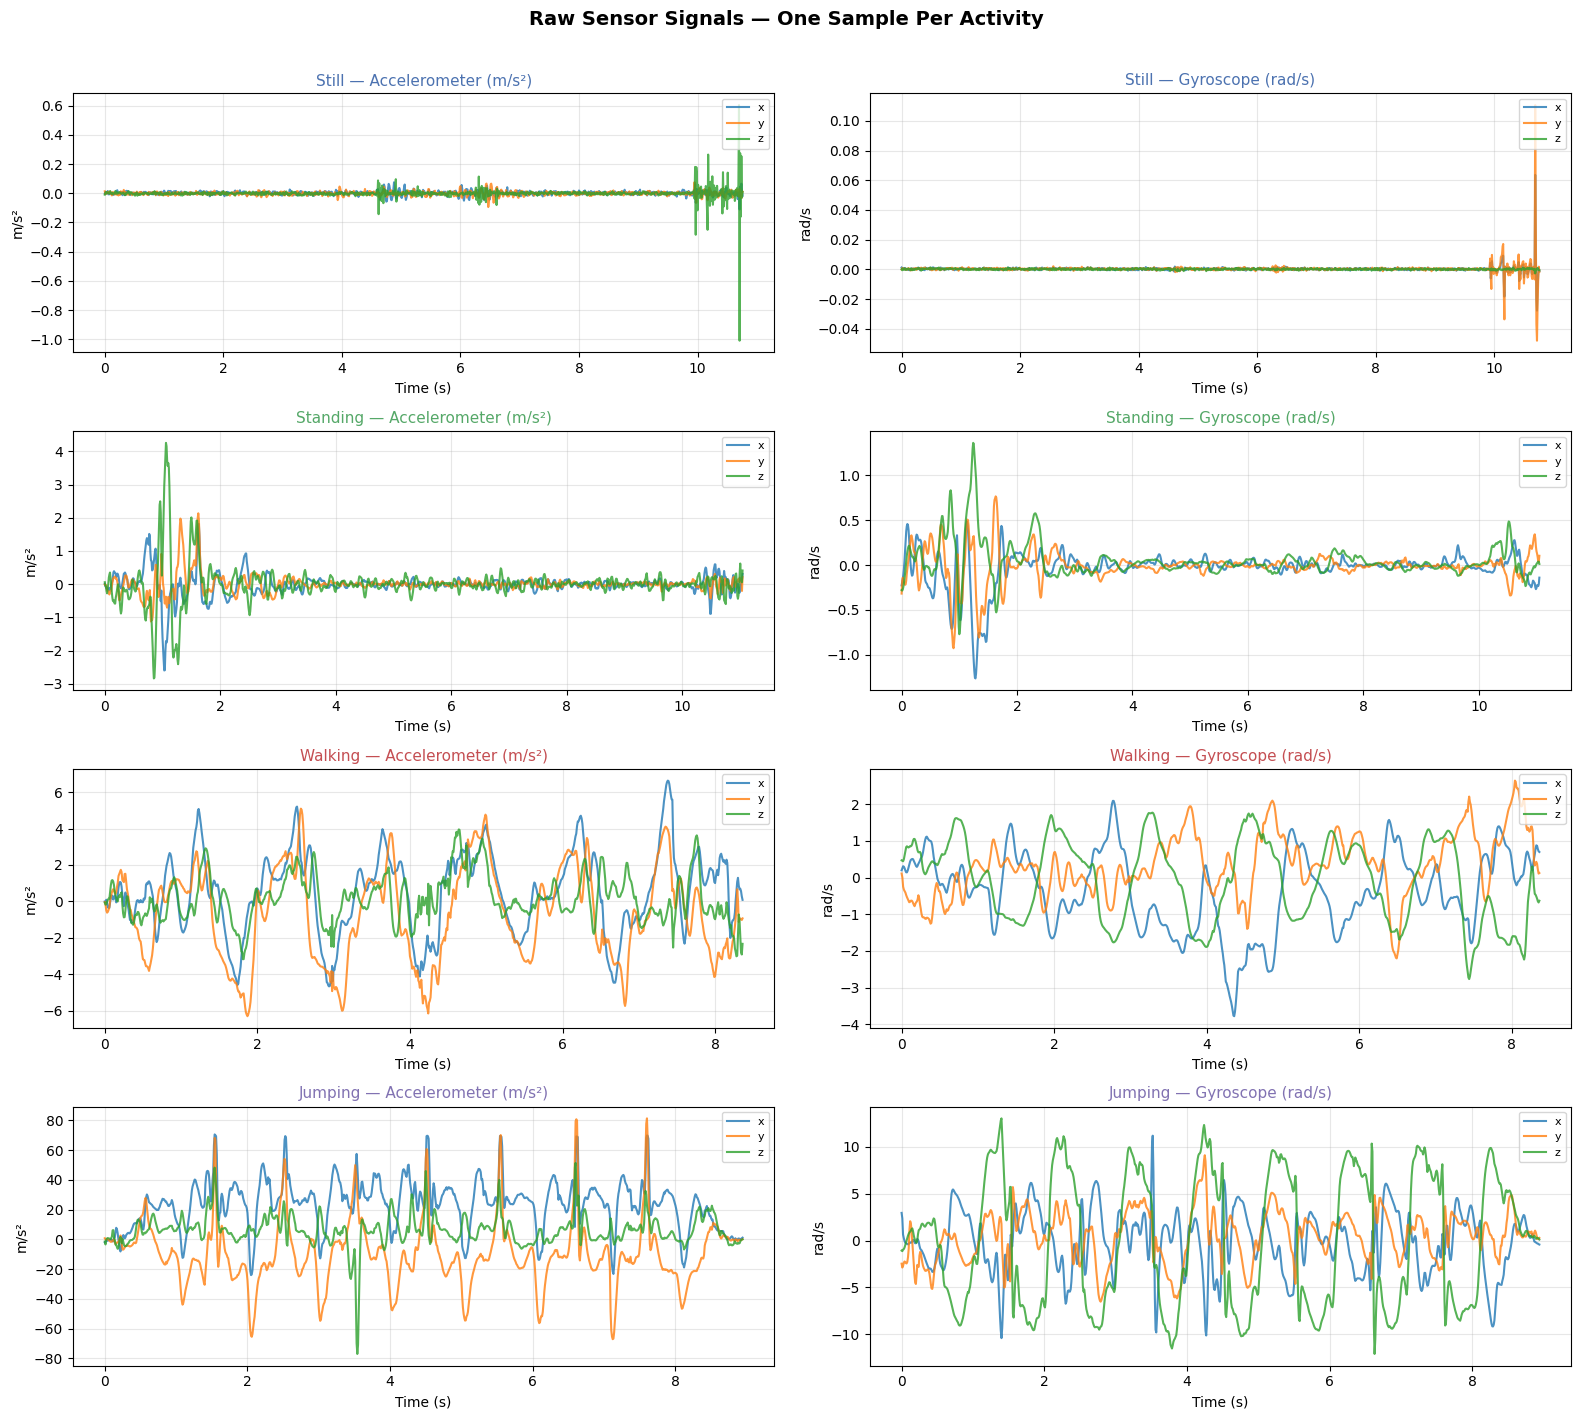

In [17]:
fig, axes = plt.subplots(len(ACTIVITIES), 2, figsize=(16, 3.5 * len(ACTIVITIES)))

for row, activity in enumerate(ACTIVITIES):
    if not raw_data[activity]:
        continue
    df    = raw_data[activity][0]
    color = ACTIVITY_COLORS[activity]

    # Use row index as time axis since seconds_elapsed may not be clean
    n = len(df)
    t = np.arange(n) / SAMPLING_RATE  # convert index to seconds

    ax = axes[row, 0]
    ax.plot(t, df['acc_x'].values, label='x', alpha=0.8)
    ax.plot(t, df['acc_y'].values, label='y', alpha=0.8)
    ax.plot(t, df['acc_z'].values, label='z', alpha=0.8)
    ax.set_title(f'{activity.title()} : Accelerometer (m/s²)', fontsize=11, color=color)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('m/s²')
    ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)

    ax = axes[row, 1]
    ax.plot(t, df['gyr_x'].values, label='x', alpha=0.8)
    ax.plot(t, df['gyr_y'].values, label='y', alpha=0.8)
    ax.plot(t, df['gyr_z'].values, label='z', alpha=0.8)
    ax.set_title(f'{activity.title()} : Gyroscope (rad/s)', fontsize=11, color=color)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('rad/s')
    ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Raw Sensor Signals : One Sample Per Activity', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Extraction

Raw sensor signals cannot be fed directly into an HMM, they must first be summarised into fixed-length feature vectors that capture the statistical and spectral properties of each activity. We use a **sliding window approach**: the signal is divided into overlapping 1-second windows, and a feature vector is computed from each window.

### Why these features?

**Time-domain features** capture the statistical properties of the raw signal amplitude:
| Feature | Why it helps |
|---|---|
| Mean | Captures the average orientation and gravity component along each axis. Still and standing have non-zero means due to gravity; walking and jumping have means close to zero as they involve symmetric motion |
| Standard Deviation | Measures how much the signal varies within the window. Higher for active movements like walking and jumping, near zero for still |
| RMS (Root Mean Square) | Measures signal energy. Particularly useful for distinguishing high-energy activities like jumping from low-energy ones like standing |
| Signal Magnitude Area (SMA) | The average sum of absolute values across all three axes. A single scalar that reflects overall movement intensity regardless of direction |
| Correlation (x-y, x-z, y-z) | Measures how coordinated the motion is between axes. Walking has a characteristic inter-axis correlation pattern due to the biomechanics of gait |

**Frequency-domain features** are derived from the Fast Fourier Transform (FFT) of the accelerometer signal and capture the rhythmic structure of each activity:
| Feature | Why it helps |
|---|---|
| Dominant Frequency | The frequency bin with the highest FFT magnitude. Walking produces a dominant peak at ~1–2 Hz; jumping at ~1–3 Hz; still and standing have no meaningful dominant frequency |
| Spectral Energy | The total power across all frequency bins. High for vigorous activities, very low for still |
| Energy in 0–3 Hz band | Captures low-frequency locomotion rhythms characteristic of walking and slow jumping |
| Energy in 3–10 Hz band | Captures higher-frequency vibrations and impact transients, particularly useful for distinguishing jumping from walking |

In total we extract **35 features** per window across both sensors and all axes.

In [18]:
def extract_features(window):
    features = []
    acc_cols = ['acc_x', 'acc_y', 'acc_z']
    gyr_cols = ['gyr_x', 'gyr_y', 'gyr_z']

    for col in acc_cols + gyr_cols:
        s = window[col].values
        features += [
            np.mean(s),
            np.std(s),
            np.sqrt(np.mean(s ** 2)),
        ]

    acc_vals = window[acc_cols].values
    gyr_vals = window[gyr_cols].values
    features.append(np.mean(np.sum(np.abs(acc_vals), axis=1)))
    features.append(np.mean(np.sum(np.abs(gyr_vals), axis=1)))

    features.append(np.corrcoef(window['acc_x'], window['acc_y'])[0, 1])
    features.append(np.corrcoef(window['acc_x'], window['acc_z'])[0, 1])
    features.append(np.corrcoef(window['acc_y'], window['acc_z'])[0, 1])

    N     = len(window)
    freqs = fftfreq(N, d=1.0/SAMPLING_RATE)
    pos   = freqs >= 0

    for col in acc_cols:
        s         = window[col].values
        fft_vals  = np.abs(fft(s))[pos]
        f_pos     = freqs[pos]
        dom_idx   = np.argmax(fft_vals[1:]) + 1
        dom_freq  = f_pos[dom_idx]
        sp_energy = np.sum(fft_vals ** 2)
        low_energy  = np.sum(fft_vals[(f_pos >= 0) & (f_pos <= 3)]  ** 2)
        high_energy = np.sum(fft_vals[(f_pos >  3) & (f_pos <= 10)] ** 2)
        features += [dom_freq, sp_energy, low_energy, high_energy]

    return np.array(features, dtype=np.float32)


def sliding_window_features(df):
    features = []
    for start in range(0, len(df) - WINDOW_SIZE + 1, STEP_SIZE):
        features.append(extract_features(df.iloc[start : start + WINDOW_SIZE]))
    return np.array(features)


def build_dataset(data_dict, activities):
    X_list, y_list, lengths = [], [], []
    for label_idx, activity in enumerate(activities):
        for df in data_dict[activity]:
            feats = sliding_window_features(df)
            if len(feats) == 0:
                continue
            X_list.append(feats)
            y_list.extend([label_idx] * len(feats))
            lengths.append(len(feats))
    return np.vstack(X_list), np.array(y_list), lengths


print('Extracting features ...')
X_train, y_train, train_lengths = build_dataset(raw_data, ACTIVITIES)
N_FEATURES = X_train.shape[1]
print(f'✓ {X_train.shape[0]} windows × {N_FEATURES} features')
for i, a in enumerate(ACTIVITIES):
    print(f'  {a:12s}: {np.sum(y_train == i):4d} windows')

Extracting features ...
✓ 889 windows × 35 features
  still       :  237 windows
  standing    :  196 windows
  walking     :  253 windows
  jumping     :  203 windows


## 8. Normalisation

Before training the HMM, all features are normalised using **Z-score standardisation** via scikit-learn's `StandardScaler`. This transforms each feature to have zero mean and unit variance across the training set.

**Why Z-score normalisation?**
- The accelerometer operates in m/s² and the gyroscope in rad/s, these are fundamentally different units and scales. Without normalisation, high-magnitude features (e.g. spectral energy) would dominate the HMM's Gaussian emission probability calculations and effectively suppress the contribution of lower-magnitude features
- Z-score is preferred over min-max scaling here because min-max is sensitive to outliers (a single extreme value in training data collapses the range of all other values), whereas Z-score is more robust
- The scaler is **fit only on the training data** using `fit_transform()`, and then applied to test data using `transform()` only : this is critical to prevent data leakage, where information from the test set influences the training pipeline

Any NaN or infinite values that may arise from constant-signal windows (e.g. a perfectly still recording with zero variance) are replaced with zero after scaling.

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print('✓ Normalisation complete.')
print(f'  Mean ≈ {X_train_scaled.mean():.4f} (expect ~0)')
print(f'  Std  ≈ {X_train_scaled.std():.4f}  (expect ~1)')

✓ Normalisation complete.
  Mean ≈ -0.0000 (expect ~0)
  Std  ≈ 1.0000  (expect ~1)


## 9. HMM Definition & Baum–Welch Training

### Model Structure

A Hidden Markov Model represents a system where the true underlying state (the activity) is hidden and can only be inferred from noisy observations (the feature vectors). Our HMM has the following components:

| Element | Our Choice | Reasoning |
|---|---|---|
| Hidden States (Z) | 4 internal states per model | Each model uses 4 states to capture sub-phases of an activity (e.g. left step, right step in walking) |
| Observations (X) | 35-dimensional normalised feature vectors | One vector per 1-second window |
| Transition Matrix (A) | Learned via Baum–Welch | Encodes how likely the activity is to stay in or move between its internal sub-states |
| Emission Probabilities (B) | Diagonal Gaussian per state | Each state emits observations drawn from a multivariate Gaussian; diagonal covariance assumes feature independence |
| Initial State Probs (π) | Uniform | No prior assumption about which sub-state starts first |

### Why one model per activity?

Rather than training a single 4-state HMM where each state represents one activity, we train **one separate GaussianHMM per activity**. Classification is then done by scoring a test sequence against all 4 models and picking the one with the highest log-likelihood. This approach is more robust for activity classification because each model can learn the internal dynamics of its own activity without interference from others.

### Baum–Welch Algorithm

The Baum–Welch algorithm is an Expectation-Maximisation (EM) procedure that optimises the HMM parameters without requiring labelled state sequences : only the observation sequences are needed. It works iteratively:

1. **E-step (Expectation):** Given the current model parameters, compute the forward probability α (probability of observations up to time t ending in state i) and the backward probability β (probability of observations from time t+1 onwards given state i at time t). These are combined to estimate the probability of being in each state at each time step
2. **M-step (Maximisation):** Use the state occupancy estimates from the E-step to re-estimate the transition matrix A, the emission Gaussian parameters (means and covariances), and the initial state probabilities π

**Convergence criterion:** Training stops automatically when the change in log-likelihood between iterations falls below **1e-4** (i.e. |ΔlogL| < 1e-4). This is a proper convergence check rather than a fixed iteration limit, ensuring the model has genuinely stabilised before training ends. A maximum of 200 iterations is also set as a safety cap.

In [20]:
models = {}

for label_idx, activity in enumerate(ACTIVITIES):
    X_act = X_train_scaled[y_train == label_idx]
    act_lengths = [
        max(0, (len(df) - WINDOW_SIZE) // STEP_SIZE + 1)
        for df in raw_data[activity]
        if (len(df) - WINDOW_SIZE) // STEP_SIZE + 1 > 0
    ]

    if len(X_act) == 0:
        print(f'  ⚠  No data for {activity}')
        continue

    model = hmm.GaussianHMM(
        n_components=N_STATES,
        covariance_type='diag',
        n_iter=200,
        tol=1e-4,
        random_state=42,
        verbose=False
    )
    model.fit(X_act, lengths=act_lengths if act_lengths else None)
    models[activity] = model
    print(f'  ✓  {activity:12s} | log-likelihood = {model.score(X_act):.2f}')

print('\n✓ All models trained.')

  ✓  still        | log-likelihood = 26657.48
  ✓  standing     | log-likelihood = 11980.24
  ✓  walking      | log-likelihood = 7324.20
  ✓  jumping      | log-likelihood = -3810.32

✓ All models trained.


## 10. Viterbi Decoding & Classification

The **Viterbi algorithm** solves the decoding problem in HMMs: given a sequence of observations, find the most likely sequence of hidden states that produced them. It uses dynamic programming to efficiently compute this without exhaustively evaluating all possible state sequences.

**How it works:**
1. Initialise a probability matrix where each cell `δ(t, i)` represents the highest probability of any path ending in state `i` at time `t`
2. At each time step, extend all paths by one step using the transition probabilities and emission probabilities
3. Track the best predecessor state at each step using a backpointer matrix
4. At the final time step, find the state with the highest probability and trace back through the backpointers to recover the full most-likely state sequence

**How we use it for classification:**
Each test window is scored against all 4 activity HMMs using the model's log-likelihood score (which internally uses the Viterbi forward computation). The activity whose HMM assigns the highest log-likelihood to the observation is chosen as the predicted class. This is equivalent to a maximum likelihood classification rule across the 4 activity models.

In [21]:
def viterbi_classify(X_scaled, models, activities):
    scores = np.full((len(X_scaled), len(activities)), -np.inf)
    for j, activity in enumerate(activities):
        if activity not in models:
            continue
        for i, x in enumerate(X_scaled):
            try:
                scores[i, j] = models[activity].score(x.reshape(1, -1))
            except Exception:
                scores[i, j] = -np.inf
    return np.argmax(scores, axis=1), scores


print('Running Viterbi on training data ...')
y_pred_train, _ = viterbi_classify(X_train_scaled, models, ACTIVITIES)
print(f'✓ Training accuracy: {np.mean(y_pred_train == y_train):.2%}')

Running Viterbi on training data ...
✓ Training accuracy: 96.85%


## 11. Transition Matrix Visualisation

The transition matrix A of each trained HMM shows the probability of moving from one internal state (row) to another (column) at each time step. We visualise these as heatmaps to understand what each model learned about the temporal dynamics of its activity.

A **strong diagonal** (high self-transition probabilities) means the model learned that each sub-state tends to persist over time, this is expected for activities like still and standing where the signal is relatively stationary. A **more distributed matrix** indicates the model learned rapid state transitions, which we expect for jumping where the signal changes quickly between the launch, airborne, and landing phases.

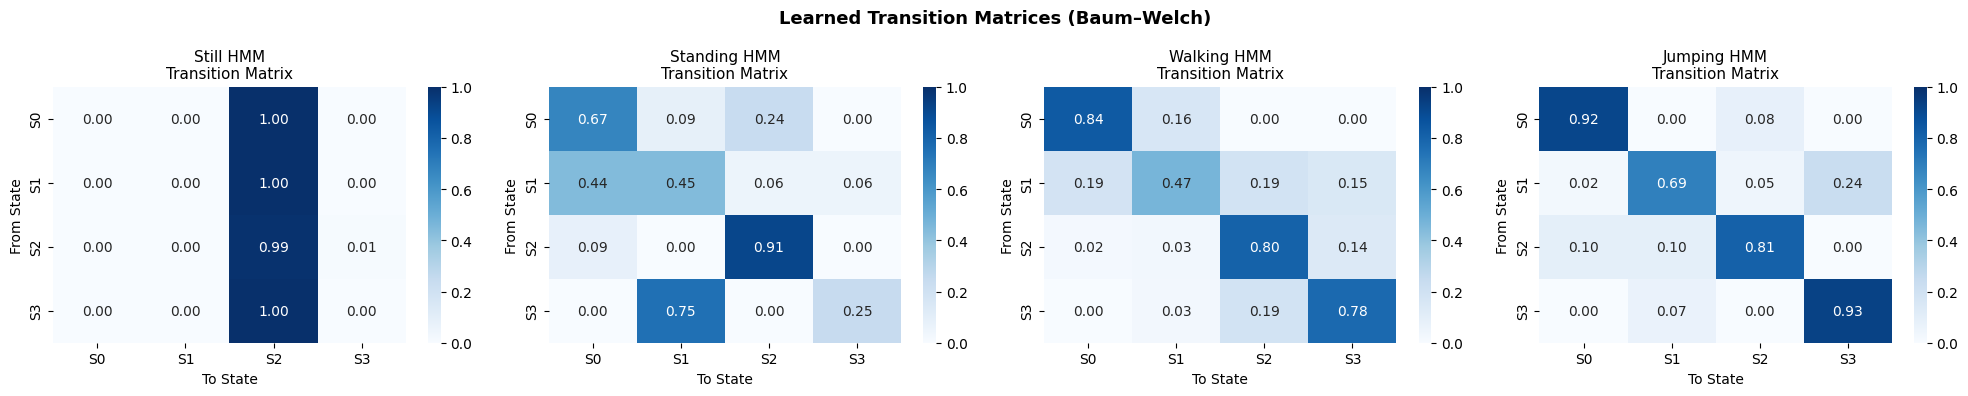

In [22]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
if len(models) == 1:
    axes = [axes]

for ax, (activity, model) in zip(axes, models.items()):
    sns.heatmap(model.transmat_, ax=ax, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[f'S{i}' for i in range(N_STATES)],
                yticklabels=[f'S{i}' for i in range(N_STATES)],
                vmin=0, vmax=1)
    ax.set_title(f'{activity.title()} HMM\nTransition Matrix', fontsize=11)
    ax.set_xlabel('To State'); ax.set_ylabel('From State')

plt.suptitle('Learned Transition Matrices (Baum–Welch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Decoded Activity Sequence : Training Data

To visually assess model performance on training data, we plot the ground truth activity labels alongside the Viterbi-decoded predictions as colour-coded bar charts over the sequence of windows. Each colour represents one activity.

The top bar shows the true labels in the order they appear in the dataset (still → standing → walking → jumping, since we loaded activities sequentially). The bottom bar shows what the model predicted for each window. Misclassifications appear as colour inconsistencies between the two bars.

This plot is useful for identifying **where** errors occur, whether they are isolated single-window misclassifications or systematic errors concentrated in certain activity regions.

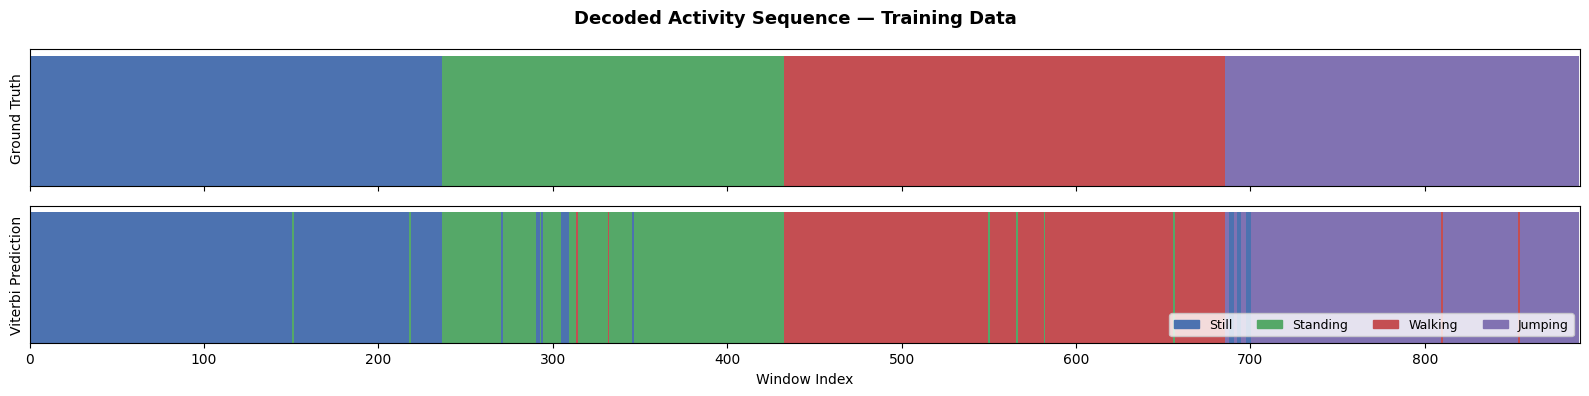

In [23]:
def plot_decoded_sequence(y_true, y_pred, activities, title='', save_path=None):
    colors = list(ACTIVITY_COLORS.values())
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 4), sharex=True)

    for ax, labels, subtitle in [(ax1, y_true, 'Ground Truth'), (ax2, y_pred, 'Viterbi Prediction')]:
        for i, label in enumerate(labels):
            ax.bar(i, 1, color=colors[label], edgecolor='none', width=1.0)
        ax.set_yticks([])
        ax.set_ylabel(subtitle, fontsize=10)
        ax.set_xlim(0, len(labels))

    patches = [mpatches.Patch(color=colors[i], label=a.title()) for i, a in enumerate(activities)]
    ax2.legend(handles=patches, loc='lower right', ncol=4, fontsize=9)
    ax2.set_xlabel('Window Index')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_decoded_sequence(
    y_train, y_pred_train, ACTIVITIES,
    title='Decoded Activity Sequence : Training Data',
    save_path='figures/decoded_train.png'
)

## 13. Evaluation on Unseen Test Data

Model generalisation is assessed by evaluating on **recordings from a completely separate session** that were never used during training. Using truly unseen data is critical because high training accuracy alone does not tell us whether the model has learned generalised activity patterns or simply memorised the training recordings.

For each activity we compute:
- **Sensitivity (Recall):** Of all windows that truly belong to this activity, what fraction did the model correctly identify? High sensitivity means the model rarely misses this activity
- **Specificity:** Of all windows that do not belong to this activity, what fraction did the model correctly exclude? High specificity means the model rarely falsely predicts this activity
- **Overall Accuracy:** The proportion of all test windows (both this activity and others) that were correctly classified

The test data is normalised using the **same StandardScaler fitted on training data**, it is not refit on the test set. This ensures the model sees test data in the same normalised space it was trained on.

In [24]:
print('Loading test data ...')
test_data = load_activity_data(TEST_DIR, ACTIVITIES)

X_test, y_test, _ = build_dataset(test_data, ACTIVITIES)
X_test_scaled     = scaler.transform(X_test)
X_test_scaled     = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print(f'\n✓ Test set: {X_test.shape[0]} windows')
y_pred_test, _ = viterbi_classify(X_test_scaled, models, ACTIVITIES)

cm = confusion_matrix(y_test, y_pred_test)
results = []
for i, activity in enumerate(ACTIVITIES):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP
    results.append({
        'Activity'        : activity.title(),
        'N Samples'       : int(cm[i, :].sum()),
        'Sensitivity'     : round(TP / (TP + FN) if (TP + FN) > 0 else 0, 3),
        'Specificity'     : round(TN / (TN + FP) if (TN + FP) > 0 else 0, 3),
        'Overall Accuracy': round((TP + TN) / cm.sum(), 3),
    })

results_df = pd.DataFrame(results)
print('\n' + results_df.to_string(index=False))
print(f'\nOverall Test Accuracy: {np.mean(y_pred_test == y_test):.2%}')

Loading test data ...
  ✓  still        → 2 files loaded
  ✓  standing     → 2 files loaded
  ✓  walking      → 2 files loaded
  ✓  jumping      → 2 files loaded

✓ Test set: 128 windows

Activity  N Samples  Sensitivity  Specificity  Overall Accuracy
   Still         31        1.000        1.000             1.000
Standing         31        0.903        0.979             0.961
 Walking         25        1.000        0.951             0.961
 Jumping         41        0.902        1.000             0.969

Overall Test Accuracy: 94.53%


## 14. Confusion Matrix

The confusion matrix provides a complete picture of classification performance by showing exactly which activities are being confused with which others. Each row represents the true activity and each column represents the predicted activity. The diagonal cells show correct classifications; off-diagonal cells show errors.

The heatmap is **row-normalised by colour** (so each row's colour intensity sums to 1.0) but **annotated with raw counts**, making it easy to see both the proportion of errors and their absolute magnitude. A near-perfect confusion matrix has dark cells only on the diagonal and light (near-zero) cells everywhere else.

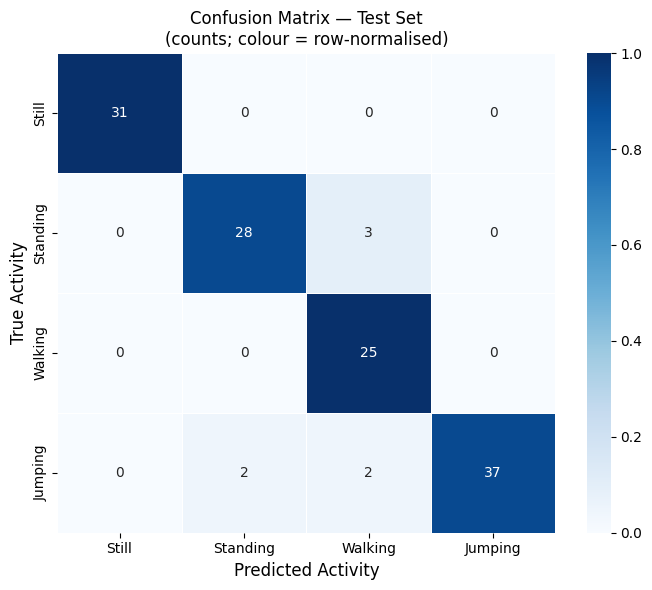

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
            xticklabels=[a.title() for a in ACTIVITIES],
            yticklabels=[a.title() for a in ACTIVITIES],
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted Activity', fontsize=12)
ax.set_ylabel('True Activity', fontsize=12)
ax.set_title('Confusion Matrix : Test Set\n(counts; colour = row-normalised)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Decoded Activity Sequence : Unseen Test Data

The same decoded sequence visualisation is applied to the test set. This gives an intuitive picture of how well the model tracks activity changes across time in recordings it has never seen before. Unlike the training sequence plot, errors here reflect genuine generalisation failures rather than fitting errors.

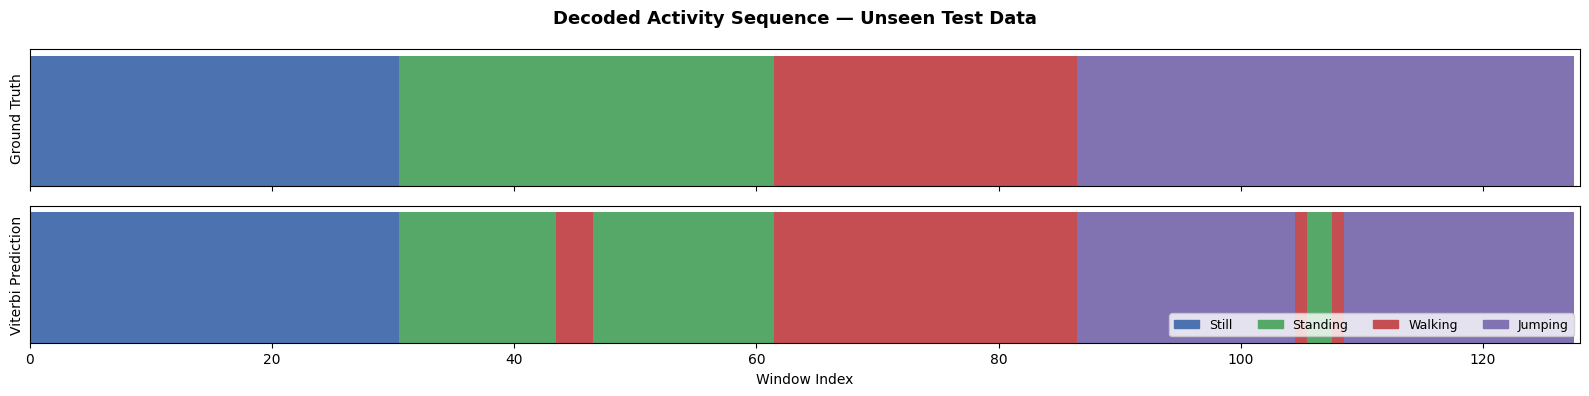

In [26]:
plot_decoded_sequence(
    y_test, y_pred_test, ACTIVITIES,
    title='Decoded Activity Sequence : Unseen Test Data',
    save_path='figures/decoded_test.png'
)

## 16. Emission Probability Visualisation

The emission probability means heatmap shows the average feature values (in the normalised Z-score space) associated with each internal state of each activity HMM. Each row is one of the 4 internal HMM states; each column is one of the first 10 features.

**How to read this:** Red cells indicate the model associates high feature values with that state; blue cells indicate low values; white indicates near-zero (close to the training mean). If the heatmaps look meaningfully different across activities, it confirms the model learned genuinely distinct feature signatures for each activity rather than converging to similar internal representations.

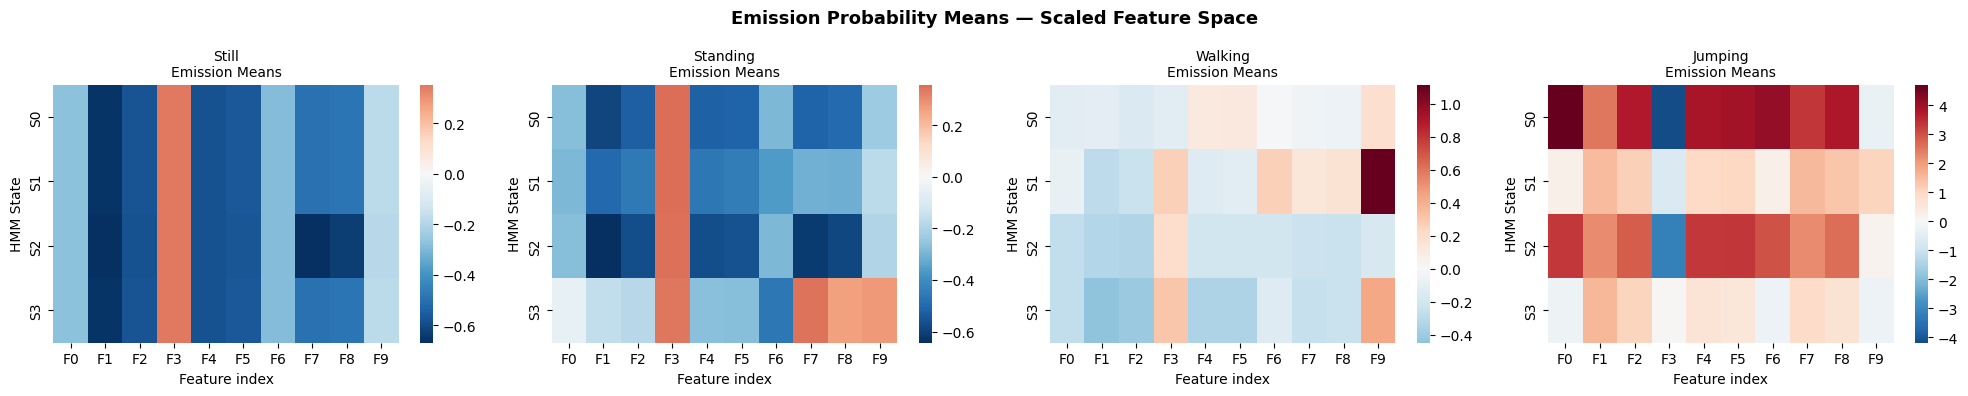

In [27]:
n_show = min(10, N_FEATURES)
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
if len(models) == 1:
    axes = [axes]

for ax, (activity, model) in zip(axes, models.items()):
    sns.heatmap(model.means_[:, :n_show], ax=ax, cmap='RdBu_r', center=0,
                xticklabels=[f'F{i}' for i in range(n_show)],
                yticklabels=[f'S{i}' for i in range(N_STATES)])
    ax.set_title(f'{activity.title()}\nEmission Means', fontsize=10)
    ax.set_xlabel('Feature index'); ax.set_ylabel('HMM State')

plt.suptitle('Emission Probability Means: Scaled Feature Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/emission_means.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Experiment Summary

A final overview of all configuration parameters, dataset statistics, and evaluation results. This table consolidates the key numbers from the full pipeline in one place for easy reference in the report.

In [28]:
print('=' * 55)
print('           EXPERIMENT SUMMARY')
print('=' * 55)
print(f'Sampling rate        : {SAMPLING_RATE} Hz')
print(f'Window size          : {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLING_RATE:.1f}s')
print(f'Step size            : {STEP_SIZE} samples (50% overlap)')
print(f'Features per window  : {N_FEATURES}')
print(f'HMM states per model : {N_STATES}')
print(f'Training windows     : {len(X_train)}')
print(f'Test windows         : {len(X_test)}')
print(f'Train accuracy       : {np.mean(y_pred_train == y_train):.2%}')
print(f'Test  accuracy       : {np.mean(y_pred_test  == y_test):.2%}')
print('=' * 55)
print(results_df.to_string(index=False))

           EXPERIMENT SUMMARY
Sampling rate        : 100 Hz
Window size          : 100 samples = 1.0s
Step size            : 50 samples (50% overlap)
Features per window  : 35
HMM states per model : 4
Training windows     : 889
Test windows         : 128
Train accuracy       : 96.85%
Test  accuracy       : 94.53%
Activity  N Samples  Sensitivity  Specificity  Overall Accuracy
   Still         31        1.000        1.000             1.000
Standing         31        0.903        0.979             0.961
 Walking         25        1.000        0.951             0.961
 Jumping         41        0.902        1.000             0.969
